In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# provisional small aoi over the sunshine coast region
# [min_lon, min_lat, max_lon, max_lat]

bbox = [152.80, -26.80, 152.90, -26.68]
time_range = "2015-01-01/2023-12-31"

In [13]:
from ecoforecast.data import search_scenes, load_cube, compute_ndvi, to_monthly

items = search_scenes(bbox, time_range)
ds = load_cube(items, bbox, resolution=100)
ndvi = compute_ndvi(ds)
monthly = to_monthly(ndvi)

In [23]:
print(monthly)

<xarray.DataArray 'ndvi' (time: 99, y: 150, x: 120)> Size: 7MB
dask.array<stack, shape=(99, 150, 120), dtype=float32, chunksize=(1, 150, 120), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 792B 2015-10-01 2015-11-01 ... 2023-12-01
  * y            (y) float64 1kB -3.057e+06 -3.057e+06 ... -3.072e+06 -3.072e+06
  * x            (x) float64 960B 2.034e+06 2.034e+06 ... 2.046e+06 2.046e+06
    spatial_ref  int32 4B 3577
Attributes:
    nodata:   -999


In [24]:
print(len(items))
print(items[0].datetime, "→", items[-1].datetime)

521
2015-10-23 00:02:46.460000+00:00 → 2023-12-30 00:04:05.660463+00:00


In [20]:
recent = search_scenes(bbox, "2024-01-01/2025-12-31")
print(len(recent))

127


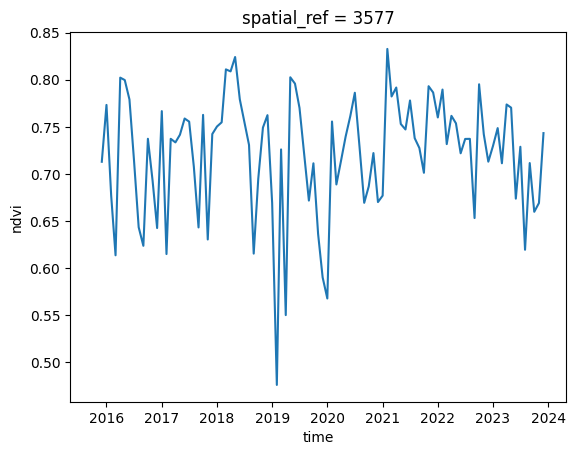

In [21]:
monthly.mean(dim=["x", "y"]).plot()

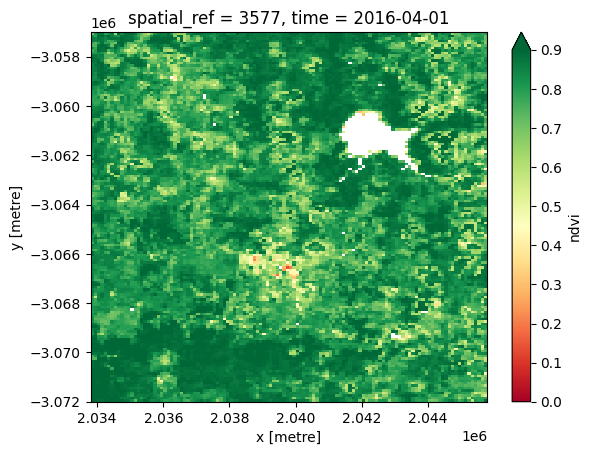

In [22]:
monthly.isel(time=6).plot(cmap="RdYlGn", vmin=0, vmax=0.9)